In [ ]:
from google.colab import files
uploaded = files.upload()


Saving breast_cancer_data.csv to breast_cancer_data (1).csv


Dataset Shape: (569, 33)

Missing Values Count:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst        

/tmp/ipykernel_13071/2023575673.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='viridis')


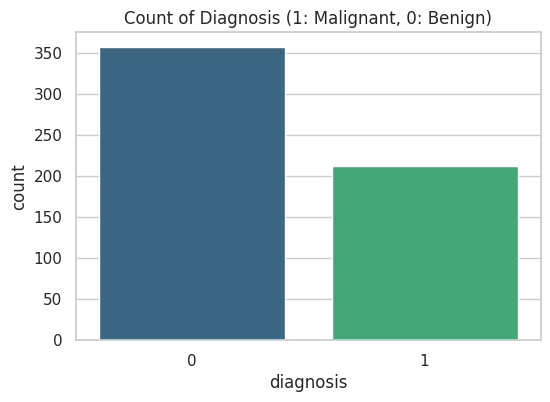

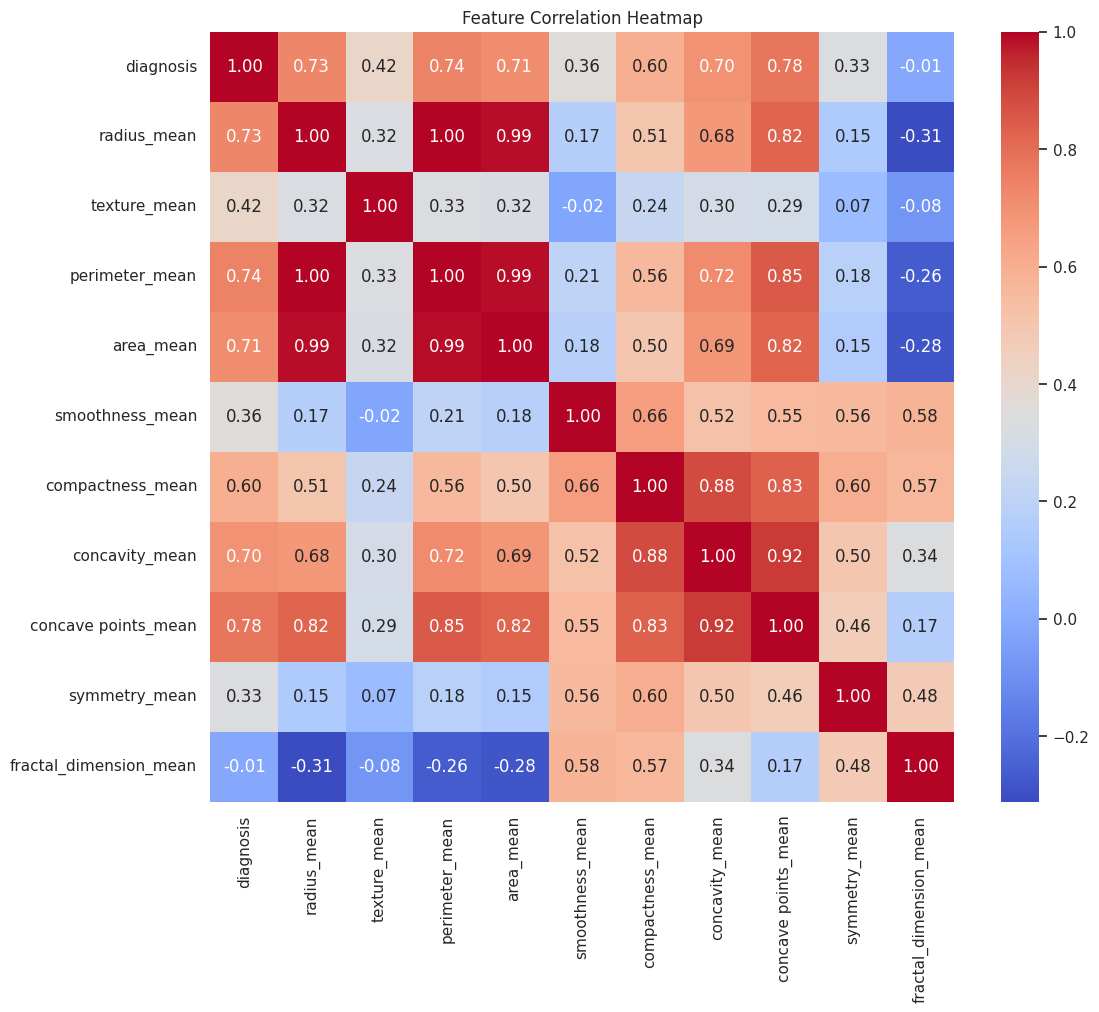


Model Performance Comparison:
Logistic Regression Accuracy: 0.9737
Decision Tree Accuracy: 0.9474
Random Forest Accuracy: 0.9649

Detailed Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



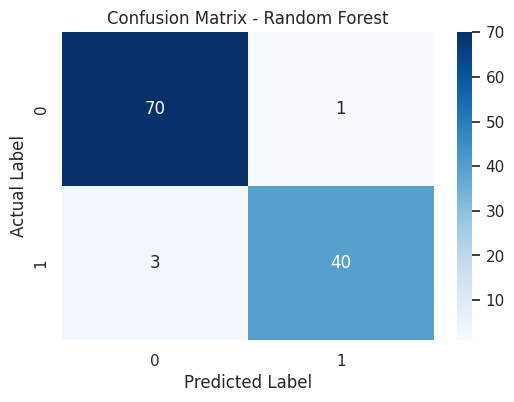

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the dataset
df = pd.read_csv('breast_cancer_data.csv')

# 2. Data Inspection
print("Dataset Shape:", df.shape)
print("\nMissing Values Count:")
print(df.isnull().sum())

# 3. Data Cleaning
# Drop 'id' and the empty 'Unnamed: 32' column
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# 4. Label Encoding (Malignant=1, Benign=0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 5. Exploratory Data Analysis (EDA)
# Visualization of Diagnosis Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='viridis')
plt.title('Count of Diagnosis (1: Malignant, 0: Benign)')
plt.show()

# Correlation Heatmap for the first 10 'mean' features
plt.figure(figsize=(12, 10))
sns.heatmap(df.iloc[:, :11].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 6. Preprocessing - Splitting and Scaling
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features is essential for models like Logistic Regression
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Model Building & Comparison
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("\nModel Performance Comparison:")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

# 8. Detailed Evaluation (Using Random Forest)
rf_model = models["Random Forest"]
rf_pred = rf_model.predict(X_test)

print("\nDetailed Classification Report (Random Forest):")
print(classification_report(y_test, rf_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()